In [1]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Classificatore basato su SVM lineari e n-grammi.

In [2]:
df_train = pd.read_pickle("../data/processed/df_train_processed.pkl")
df_val = pd.read_pickle("../data/processed/df_val_processed.pkl")
df_test = pd.read_pickle("../data/processed/df_test_processed.pkl")

In [3]:
df_train.head()

,text,label,tokens,pos,lemmas,tokens_processed,pos_processed,lemmas_processed
0,"Eppure, nel mezzo di queste scorse commerciali...",1,"[eppure, nel, mezzo, di, queste, scorse, comme...","[CCONJ, ADP, NOUN, ADP, DET, NOUN, ADJ, DET, A...","[eppure, in il, mezzo, di, questo, scorsa, com...",eppure nel mezzo di queste scorse commerciali ...,CCONJ ADP NOUN ADP DET NOUN ADJ DET ADJ NOUN A...,eppure in il mezzo di questo scorsa commercial...
1,"""È una cosa che sto valutando di fare da fine ...",0,"[è, una, cosa, che, sto, valutando, di, fare, ...","[AUX, DET, NOUN, PRON, AUX, VERB, ADP, VERB, A...","[essere, uno, cosa, che, stare, valutare, di, ...",è una cosa che sto valutando di fare da fine a...,AUX DET NOUN PRON AUX VERB ADP VERB ADP NOUN N...,essere uno cosa che stare valutare di fare da ...
2,Il caso Pirelli si presenta non come un sempli...,1,"[il, caso, pirelli, si, presenta, non, come, u...","[DET, NOUN, PROPN, PRON, VERB, ADV, ADP, DET, ...","[il, caso, pirelli, si, presentare, non, come,...",il caso pirelli si presenta non come un sempli...,DET NOUN PROPN PRON VERB ADV ADP DET ADJ NOUN ...,il caso pirelli si presentare non come uno sem...
3,Poi la direzione distrettuale antimafia di Lec...,0,"[poi, la, direzione, distrettuale, antimafia, ...","[ADV, DET, NOUN, ADJ, ADJ, ADP, PROPN, ADP, DE...","[poi, il, direzione, distrettuale, antimafia, ...",poi la direzione distrettuale antimafia di lec...,ADV DET NOUN ADJ ADJ ADP PROPN ADP DET NOUN PR...,poi il direzione distrettuale antimafia di lec...
4,Il cambio di programma si è configurato in una...,1,"[il, cambio, di, programma, si, è, configurato...","[DET, NOUN, ADP, NOUN, PRON, AUX, VERB, ADP, D...","[il, cambio, di, programma, si, essere, config...",il cambio di programma si è configurato in una...,DET NOUN ADP NOUN PRON AUX VERB ADP DET NOUN V...,il cambio di programma si essere configurare i...


In [4]:
X_train=df_train['lemmas_processed'].copy()
y_train=df_train['label'].copy()
X_test=df_test['lemmas_processed'].copy()
y_test=df_test['label'].copy()

In [5]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])
model.fit(X_train, y_train)

pred = model.predict(X_test)

# accuracy
#print("Accuracy:", accuracy_score(y_test, pred))
# classification report
print(classification_report(y_test, pred, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

           0       0.75      0.97      0.84       500
           1       0.96      0.67      0.79       500

    accuracy                           0.82      1000
   macro avg       0.85      0.82      0.82      1000
weighted avg       0.85      0.82      0.82      1000



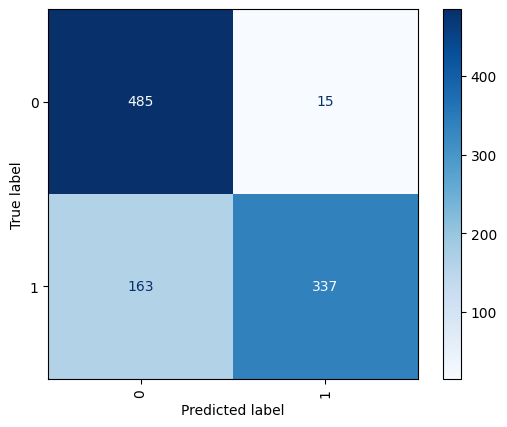

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, xticks_rotation='vertical', cmap='Blues');

### Valutazione tramite procedura di cross-validation a 5 fold sul training set per selezionare il modello migliore

In [7]:
configs = {
    # 1. ESPERIMENTI SULLE FORME (TOKENS)
    "forme_unigrammi": {
        "colonna": "tokens_processed",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "forme_unigrammi_bigrammi": {
        "colonna": "tokens_processed",
        "analyzer": "word",
        "ngram_range": (1, 2)
    },
    
    # 2. ESPERIMENTI SUI LEMMI
    "lemmi_unigrammi": {
        "colonna": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "lemmi_bigrammi": {
        "colonna": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (2, 2)
    },
    
    # 3. ESPERIMENTI SULLE PART-OF-SPEECH (SINTASSI)
    "pos_bigrammi": {
        "colonna": "pos_processed",
        "analyzer": "word",
        "ngram_range": (2, 2)
    },
    "pos_trigrammi": {
        "colonna": "pos_processed",
        "analyzer": "word",
        "ngram_range": (3, 3)
    },
    
    # 4. ESPERIMENTI SUI CARATTERI
    # Nota: per i caratteri usiamo la colonna del testo originale 'text'
    "caratteri_3_5_grammi": {
        "colonna": "text",
        "analyzer": "char",
        "ngram_range": (3, 5)
    }
}

In [8]:
for nome_test, params in configs.items():

    print(f"\nEsecuzione: {nome_test}")

    vectorizer = TfidfVectorizer(
        analyzer=params["analyzer"],
        ngram_range=params["ngram_range"]
    )

    X_train_vettori = vectorizer.fit_transform(
        df_train[params["colonna"]]
    )

    model = LinearSVC()

    scores = cross_val_score(
        model,
        X_train_vettori,
        y_train,
        cv=5,
        scoring="f1_macro"
    )

    print("Scores fold:", scores)
    print("Media:", np.mean(scores))


Esecuzione: forme_unigrammi
Scores fold: [0.969988   0.97499    0.979998   0.98749805 0.97249845]
Media: 0.9769944981208436

Esecuzione: forme_unigrammi_bigrammi
Scores fold: [0.96748354 0.97749311 0.9749975  0.98749992 0.97249983]
Media: 0.9759947791107797

Esecuzione: lemmi_unigrammi
Scores fold: [0.96248851 0.9724957  0.96499212 0.98499662 0.95749761]
Media: 0.9684941142538083

Esecuzione: lemmi_bigrammi
Scores fold: [0.95747847 0.96749817 0.9674998  0.98249989 0.96      ]
Media: 0.9669952665494813

Esecuzione: pos_bigrammi
Scores fold: [0.93247932 0.919998   0.92249952 0.92       0.91749948]
Media: 0.9224952643472095

Esecuzione: pos_trigrammi
Scores fold: [0.9449945  0.9449656  0.9249925  0.94499862 0.93249958]
Media: 0.9384901610580092

Esecuzione: caratteri_3_5_grammi
Scores fold: [0.98249727 0.9849985  0.98249989 0.98999975 0.98249989]
Media: 0.9844990592580108


In [9]:
#scores = [0.9449945, 0.9449656, 0.9249925, 0.94499862, 0.93249958]

#print("Media:", np.mean(scores))
#print("Std:", np.std(scores))

### Valutazione prestazioni del modello scelto attraverso la 5 fold cross-validation sui set di validazione e di test

In [10]:
"""# 4. ESPERIMENTI SUI CARATTERI
    # Nota: per i caratteri usiamo la colonna del testo originale 'text'
    "caratteri_3_5_grammi": {
        "colonna": "text",
        "analyzer": "char",
        "ngram_range": (3, 5)
    }"""

'# 4. ESPERIMENTI SUI CARATTERI\n    # Nota: per i caratteri usiamo la colonna del testo originale \'text\'\n    "caratteri_3_5_grammi": {\n        "colonna": "text",\n        "analyzer": "char",\n        "ngram_range": (3, 5)\n    }'

In [11]:
vectorizer_val = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5)
    )

X_val_vettori = vectorizer_val.fit_transform(
        df_val['text']
    )

model_val = LinearSVC()
scores = cross_val_score(
    model_val,
    X_val_vettori,
    df_val['label'],
    cv=5,
    scoring="f1_macro"
)

print("Scores fold:", scores)
print("Media:", np.mean(scores))

Scores fold: [0.969997   0.96       0.96499212 0.97499437 0.98499662]
Media: 0.9709960241804481


In [12]:
vectorizer_test = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5)
)

X_test_vettori = vectorizer_test.fit_transform(
    df_test['text']
)

model_test = LinearSVC()
scores_test = cross_val_score(
    model_test,
    X_test_vettori,
    df_test['label'],
    cv=5,
    scoring="f1_macro"
)

print("Scores fold (Test):", scores_test)
print("Media (Test):", np.mean(scores_test))

Scores fold (Test): [0.919992   0.91992794 0.86496962 0.9249531  0.909991  ]
Media (Test): 0.9079667294580694


In [13]:
df_train

,text,label,tokens,pos,lemmas,tokens_processed,pos_processed,lemmas_processed
0,"Eppure, nel mezzo di queste scorse commerciali...",1,"[eppure, nel, mezzo, di, queste, scorse, comme...","[CCONJ, ADP, NOUN, ADP, DET, NOUN, ADJ, DET, A...","[eppure, in il, mezzo, di, questo, scorsa, com...",eppure nel mezzo di queste scorse commerciali ...,CCONJ ADP NOUN ADP DET NOUN ADJ DET ADJ NOUN A...,eppure in il mezzo di questo scorsa commercial...
1,"""È una cosa che sto valutando di fare da fine ...",0,"[è, una, cosa, che, sto, valutando, di, fare, ...","[AUX, DET, NOUN, PRON, AUX, VERB, ADP, VERB, A...","[essere, uno, cosa, che, stare, valutare, di, ...",è una cosa che sto valutando di fare da fine a...,AUX DET NOUN PRON AUX VERB ADP VERB ADP NOUN N...,essere uno cosa che stare valutare di fare da ...
2,Il caso Pirelli si presenta non come un sempli...,1,"[il, caso, pirelli, si, presenta, non, come, u...","[DET, NOUN, PROPN, PRON, VERB, ADV, ADP, DET, ...","[il, caso, pirelli, si, presentare, non, come,...",il caso pirelli si presenta non come un sempli...,DET NOUN PROPN PRON VERB ADV ADP DET ADJ NOUN ...,il caso pirelli si presentare non come uno sem...
3,Poi la direzione distrettuale antimafia di Lec...,0,"[poi, la, direzione, distrettuale, antimafia, ...","[ADV, DET, NOUN, ADJ, ADJ, ADP, PROPN, ADP, DE...","[poi, il, direzione, distrettuale, antimafia, ...",poi la direzione distrettuale antimafia di lec...,ADV DET NOUN ADJ ADJ ADP PROPN ADP DET NOUN PR...,poi il direzione distrettuale antimafia di lec...
4,Il cambio di programma si è configurato in una...,1,"[il, cambio, di, programma, si, è, configurato...","[DET, NOUN, ADP, NOUN, PRON, AUX, VERB, ADP, D...","[il, cambio, di, programma, si, essere, config...",il cambio di programma si è configurato in una...,DET NOUN ADP NOUN PRON AUX VERB ADP DET NOUN V...,il cambio di programma si essere configurare i...
...,...,...,...,...,...,...,...,...
1995,In un breve decennio i dispositivi hanno assun...,1,"[in, un, breve, decennio, i, dispositivi, hann...","[ADP, DET, ADJ, NOUN, DET, NOUN, AUX, VERB, DE...","[in, uno, breve, decennio, il, dispositivo, av...",in un breve decennio i dispositivi hanno assun...,ADP DET ADJ NOUN DET NOUN AUX VERB DET NOUN AD...,in uno breve decennio il dispositivo avere ass...
1996,"Nella scorsa settimana, in un’intervista appen...",1,"[nella, scorsa, settimana, in, un’, intervista...","[ADP, ADJ, NOUN, ADP, DET, NOUN, ADV, VERB, AD...","[in il, scorso, settimana, in, uno, intervista...",nella scorsa settimana in un’ intervista appen...,ADP ADJ NOUN ADP DET NOUN ADV VERB ADP NOUN AD...,in il scorso settimana in uno intervista appen...
1997,"Finirà di scontare la pena, fino al 5 dicembre...",0,"[finirà, di, scontare, la, pena, fino, al, 5, ...","[VERB, ADP, VERB, DET, NOUN, ADP, DET, NUM, NO...","[finirà, di, scontare, il, pena, fino, a il, 5...",finirà di scontare la pena fino al 5 dicembre ...,VERB ADP VERB DET NOUN ADP DET NUM NOUN NUM AD...,finirà di scontare il pena fino a il 5 dicembr...
1998,Gli scienziati dell’Università di Oxford e del...,1,"[gli, scienziati, dell’, università, di, oxfor...","[DET, NOUN, ADP, NOUN, ADP, PROPN, CCONJ, ADP,...","[il, scienziato, di il, università, di, oxford...",gli scienziati dell’ università di oxford e de...,DET NOUN ADP NOUN ADP PROPN CCONJ ADP PROPN PR...,il scienziato di il università di oxford e di ...


## 2. Classificatore basato su Support Vector Machine (SVM) lineari e informazioni linguistiche non lessicali.

In [14]:
# --- PER IL TRAIN ---
df_features_train = pd.read_csv('../data/processed/data_task2/train_UD.csv', delimiter='\t')
# 1. Estrai l'ID
df_features_train['doc_id'] = df_features_train['Filename'].str.extract(r'(\d+)').astype(int)
# 2. ORDINA per doc_id per garantire il perfetto allineamento con df_train originale
df_features_train = df_features_train.sort_values(by='doc_id').set_index('doc_id')
# 3. Isola X (rimuovendo anche Filename)
X_train_ud = df_features_train.drop(columns=['Filename'])
y_train_ud = df_train['label'].copy()

/tmp/ipykernel_15012/1967343043.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features_train['doc_id'] = df_features_train['Filename'].str.extract(r'(\d+)').astype(int)


In [16]:
# --- PER IL TEST ---

profiling_test_path='../data/processed/data_task2/test_UD.csv'
df_features_test = pd.read_csv(profiling_test_path, delimiter='\t')
# 1. Estrai l'ID
df_features_test['doc_id'] = df_features_test['Filename'].str.extract(r'(\d+)').astype(int)
# 2. ORDINA per doc_id per allinearlo a df_test originale
df_features_test = df_features_test.sort_values(by='doc_id').set_index('doc_id')
# 3. Isola X
X_test_ud = df_features_test.drop(columns=['Filename'])
y_test_ud = df_test['label'].copy()

/tmp/ipykernel_15012/1832154943.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features_test['doc_id'] = df_features_test['Filename'].str.extract(r'(\d+)').astype(int)


In [17]:
"""Cosa sta succedendo (Il problema)
Se leggi attentamente l'errore:
    Nel Training set, Profiling-UD ha estratto una colonna chiamata verbs_num_pers_dist_+.
    Nel Test set, la stessa identica colonna è stata estratta con il nome verbs_num_pers_dist_+3.
Perché succede? Profiling-UD rileva le feature in base ai testi che analizza. 
Se nel training set non c'erano verbi alla terza persona che rispecchiavano quella codifica esatta (o viceversa), lo strumento tronca o modifica leggermente il nome della colonna nel CSV. StandardScaler si accorge che i nomi e l'ordine delle 141 colonne non corrispondono al millimetro tra Train e Test e blocca tutto per sicurezza."""
# Forza il test set ad avere le stesse identiche colonne (e ordine) del train set
X_test_ud = X_test_ud.reindex(columns=X_train_ud.columns, fill_value=0)

In [18]:
model_ud = Pipeline([
    ("scaler", StandardScaler()),  # Scala i numeri di Profiling-UD
    ("clf", LinearSVC())           # Classificatore SVM
])

# Addestramento
model_ud.fit(X_train_ud, y_train_ud)

# Predizione
pred = model_ud.predict(X_test_ud)

# Stampa i risultati corretti
print(classification_report(y_test_ud, pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       500
           1       0.92      0.83      0.87       500

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [19]:
# 1. Ottieni le distanze dal confine della SVM
distanze = model_ud.decision_function(X_test_ud)

# 2. Crea un DataFrame per l'analisi dell'incertezza
df_incertezza = pd.DataFrame({
    'distanza_assoluta': np.abs(distanze),
    'distanza_reale': distanze,
    'testo': df_test['text'],
    'label_reale': y_test_ud,
    'predizione': pred  # le predizioni che hai già calcolato prima
})

# 3. Ordina in base alla distanza più vicina a zero e prendi i primi 5
i_5_più_incerti = df_incertezza.sort_values(by='distanza_assoluta').head(5)

# 4. Visualizza il risultato
display(i_5_più_incerti[['distanza_reale', 'label_reale', 'predizione', 'testo']])

,distanza_reale,label_reale,predizione,testo
815,-0.003327,1,0,Le previsioni meteo degli ultimi giorni preann...
823,0.004401,1,1,L’obiettivo? Ridefinire i equilibri tra esecut...
108,0.010565,0,1,Il confine con la Colombia è il teatro dei mag...
194,-0.012522,1,0,"Una storia iniziata tra mille polemiche, tra c..."
276,0.014760,1,1,L'appuntamento è dunque fissato per il prossim...


In [20]:
print(i_5_più_incerti)

     distanza_assoluta  distanza_reale  \
815           0.003327       -0.003327   
823           0.004401        0.004401   
108           0.010565        0.010565   
194           0.012522       -0.012522   
276           0.014760        0.014760   

                                                 testo  label_reale  \
815  Le previsioni meteo degli ultimi giorni preann...            1   
823  L’obiettivo? Ridefinire i equilibri tra esecut...            1   
108  Il confine con la Colombia è il teatro dei mag...            0   
194  Una storia iniziata tra mille polemiche, tra c...            1   
276  L'appuntamento è dunque fissato per il prossim...            1   

     predizione  
815           0  
823           1  
108           1  
194           0  
276           1  


### 20 features più importanti

In [21]:
# Recuperiamo i pesi assegnati dalla SVM alle colonne di Profiling-UD
pesi = model_ud['clf'].coef_[0]

df_feature_importanti = pd.DataFrame({
    'Feature': X_train_ud.columns,
    'Peso': pesi,
    'Peso_Assoluto': np.abs(pesi)
})

# Prendi le 20 più significative
le_20_dominanti = df_feature_importanti.sort_values(by='Peso_Assoluto', ascending=False).head(20)
print(le_20_dominanti[['Feature', 'Peso']])

                         Feature      Peso
1                       n_tokens -2.419553
93               dep_dist_advmod  1.874903
10                 upos_dist_ADV -1.525584
25               lexical_density -1.457214
80        n_prepositional_chains  1.309277
7            ttr_form_chunks_200 -1.297201
105                 dep_dist_det -1.232503
16                 upos_dist_NUM -1.121213
20               upos_dist_PUNCT  1.016801
18                upos_dist_PRON -0.999782
13                 upos_dist_DET  0.930042
115        dep_dist_flat:foreign -0.893910
98                 dep_dist_case -0.800125
23                upos_dist_VERB -0.775194
79   avg_prepositional_chain_len -0.763023
135    avg_subordinate_chain_len -0.715276
9                  upos_dist_ADP  0.606542
19               upos_dist_PROPN -0.587581
91            dep_dist_acl:relcl  0.542539
120               dep_dist_nsubj  0.501054
